<center><p float="center">
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="400" height="200"/>
</p></center>

<h1><center><font size=10>Analytics Lifecycle - Case Study</center></font></h1>
<h1><center>Exploratory Data Analysis - Playstore Ad Revenue</center></h1>





### 0.0 Problem Statement

#### 0.1 Business Context




<center><p float="center">
  <img src="https://www.reshot.com/preview-assets/icons/XL3Q6MFW5T/play-store-XL3Q6MFW5T.svg" width="200" height="200"/> </center>
<p style="text-align: left;">Advertising, as an important marketing communication tool, plays a key role in selling or promoting any product in today&apos;s market. Almost every business wants their product to be promoted via various channels such as websites, apps, emails, and other offline communications</p>
<p style="text-align: left;">Android is the most popular mobile operating system, accounting for <a href="https://financesonline.com/number-of-smartphone-users-worldwide/#:~:text=Smartphone%20Operating%20System%20Preference%3A%20Android%20vs%20iOS,-Android%20democratized%20smartphone&text=Various%20sources%20put%20the%20total,2021%20(StatCounter%2C%202021).">72.05%&nbsp;</a>of the market. The Google Play Store is the Android app store or platform where all applications are available for download and use by users.&nbsp;The Google Play store&apos;s primary source of revenue is advertisements</p>
<p style="text-align: left;">The Google Play Store is currently experiencing a significant drop in user numbers. They have hired Tellio Communication Pvt Ltd to analyze the data and understand the usage &amp; download trends of applications available on the Google Play Store so that they can decide whether to focus on promoting advertisements on specific applications that are trending in the market and can lead to maximizing profit</p>

#### 0.2 Objective


<p style="text-align: left;">Advertising is a major source of revenue, and customer volume is directly related to the advertisement conversion rate. The company is experiencing a significant drop in its user base, which is resulting in revenue loss. The company wants to know what factors contributed to the user drop. User loss is also affecting the company&apos;s ability to acquire new companies so that they can advertise their products</p>

#### 0.3 Data Dictionary




- **app_id** - Unique application ID
- **app_name** - Application name
- **app_category** - Application Category
- **app_size_in_mb** - Application size in MB
- **free_or_paid** - Whether the application is free or paid
- **price_in_usd** - Application price in US Dollars
- **content_rating** - To which age group does the application belong?
- **number_of_installs** - No of installations per week
- **average_screen_time** - Average time spend by the user in minutes per week
- **adv_supported** - Whether the app supported application
- **active_users** - The number of app users who are active in a given week.
- **no_of_short_ads_per_hour** - No of short ads visible in an hour
- **no_of_long_ads_per_hour** - No of long ads visible in an hour
- **adv_revenue** - Revenue generated by advertisement in $
- **updated_date** - Week start

#### 0.4 Questions & Hypothesis to answer



**1-** How is the revenue trending week over week?

**2-** Which are the categories that generate 70% of my advertising revenue?

**3-** Do the top 5 revenue-generating categories have significantly higher average screen time per week compared to the rest of the categories?

**4-** How is the revenue trending week over week for the top 5 revenue generating categories?

**5-** Is the downward trend happening because of a reduction in the number of installs week over week?

**6-** Is the downward trend happening because of a reduction in the number of active users week over week?

**7-** Why are active users decreasing? Could it be because of the increase in the number of short and long ads per hour? Could this be hampering user experience, leading to lower customer engagement?


### 1.0 Import Python Libraries

In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### 2.0 Import data into Google Colab

In [ ]:
df = pd.read_csv('playstore_revenue_analysis.csv')

### 3.0 Descriptive Analysis

#### 3.1 Display the first and last 5 rows of the dataset

This is done to check if the dataset was loaded properly with the correct columns and formatting

In [ ]:
df.head()

,app_id,app_name,app_category,app_size_in_mb,free_or_paid,price_in_usd,content_rating,number_of_installs,average_screen_time,adv_supported,active_users,no_of_short_ads_per_hour,no_of_long_ads_per_hour,adv_revenue,updated_date,screentime_category
0,1,News.aw,NEWS AND MAGAZINES,1.0,Free,0.00,Everyone,375,50,1,66010,3,1,11139.19,2022-01-03,Low
1,2,BL PowerPoint Remote,TOOLS,1.0,Paid,3.99,Everyone,96,12,1,19349,4,2,4837.25,2022-01-03,Low
2,3,WISE- MOBILE PORTAL,TOOLS,1.0,Free,0.00,Everyone,63,6,1,16298,2,0,901.44,2022-01-03,Low
3,4,go41cx,FAMILY,1.0,Paid,10.00,Everyone,590,103,1,32478,3,1,5480.66,2022-01-03,Medium
4,5,German Vocabulary Trainer,FAMILY,1.0,Free,0.00,Everyone,837,50,1,43808,3,2,10678.20,2022-01-03,Low


In [ ]:
df.tail()

,app_id,app_name,app_category,app_size_in_mb,free_or_paid,price_in_usd,content_rating,number_of_installs,average_screen_time,adv_supported,active_users,no_of_short_ads_per_hour,no_of_long_ads_per_hour,adv_revenue,updated_date,screentime_category
93847,10349,Solitaire+,GAME,20.0,Paid,2.99,Everyone,2031,183,1,32978,6,1,8607.26,2022-03-21,Medium
93848,10351,Photo Editor Collage Maker Pro,PHOTOGRAPHY,20.0,Free,0.00,Everyone,181,9,1,15741,4,2,3885.59,2022-03-21,Low
93849,10355,Chat For Strangers - Video Chat,SOCIAL,20.0,Free,0.00,Mature 17+,1041,222,1,13257,3,0,1232.90,2022-03-21,High
93850,10356,Frim: get new friends on local chat rooms,SOCIAL,20.0,Free,0.00,Mature 17+,1271,234,1,17377,2,0,1077.37,2022-03-21,High
93851,10357,The SCP Foundation DB fr nn5n,BOOKS AND REFERENCE,20.0,Free,0.00,Mature 17+,14,82,1,6424,3,2,1369.31,2022-03-21,Medium


#### 3.2 Check the shape of the dataset

This is done to check if we loaded all of the rows the columns are not missing any data

In [ ]:
# checking shape of the data
print("There are", df.shape[0], 'rows and', df.shape[1], "columns")

There are 93852 rows and 16 columns


#### 3.3 Check the data types of the columns for the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93852 entries, 0 to 93851
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   app_id                    93852 non-null  int64  
 1   app_name                  93852 non-null  object 
 2   app_category              93852 non-null  object 
 3   app_size_in_mb            93852 non-null  float64
 4   free_or_paid              93852 non-null  object 
 5   price_in_usd              93852 non-null  float64
 6   content_rating            93852 non-null  object 
 7   number_of_installs        93852 non-null  int64  
 8   average_screen_time       93852 non-null  int64  
 9   adv_supported             93852 non-null  int64  
 10  active_users              93852 non-null  int64  
 11  no_of_short_ads_per_hour  93852 non-null  int64  
 12  no_of_long_ads_per_hour   93852 non-null  int64  
 13  adv_revenue               93852 non-null  float64
 14  update

#### 3.4 Check the missing values in the dataset

In [ ]:
# checking missing values using isnull function
df.isnull().sum()

app_id                      0
app_name                    0
app_category                0
app_size_in_mb              0
free_or_paid                0
price_in_usd                0
content_rating              0
number_of_installs          0
average_screen_time         0
adv_supported               0
active_users                0
no_of_short_ads_per_hour    0
no_of_long_ads_per_hour     0
adv_revenue                 0
updated_date                0
screentime_category         0
dtype: int64

**Observation**: There are no missing values in the data

#### 3.5 Check for duplicate entries in the data

In [ ]:
df.duplicated().sum()

0

This will be zero as we cleaned all the duplicates during the pre-processing with did with SQL

#### 3.6 Check the statistical summary of the data 

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
app_id,93852.0,5222.586881,2949.488757,1.00,2704.00,5306.000,7740.00,10357.00
app_size_in_mb,93852.0,22.576631,22.240083,0.01,5.90,18.000,28.00,100.00
price_in_usd,93852.0,0.789131,14.006241,0.00,0.00,0.000,0.00,400.00
number_of_installs,93852.0,737.795923,766.262524,10.00,108.00,444.000,1160.25,2999.00
average_screen_time,93852.0,75.143449,62.900593,5.00,18.00,66.000,104.00,359.00
adv_supported,93852.0,1.000000,0.000000,1.00,1.00,1.000,1.00,1.00
active_users,93852.0,27521.743724,19459.707685,1102.00,13691.00,21225.000,39090.25,97895.00
no_of_short_ads_per_hour,93852.0,2.566157,1.184102,1.00,2.00,2.000,3.00,6.00
no_of_long_ads_per_hour,93852.0,1.322550,0.843951,0.00,1.00,1.000,2.00,3.00
adv_revenue,93852.0,4616.159369,4111.681081,62.93,1625.55,3320.425,6664.96,36881.91


The above table displays the descriptive analysis for numeric columns

**Observations**:
- For price_in_usd, the 25th, 50th and 75th percentile are Zero - this means that more than 75% of the applications on the playstore are free (this could be higher when we do deeper dive during the univariate analysis)
- 75% of the app_size if within 30 MB as developers tend to keep the apk size of free applications small or maybe there could be size restrictions set for certain category of apps
- 75% of the applications keep customers engaged upto 100 minutes per week - this is a lot of potential to show ads which generate revenue (per hour of screentime, you can show upto a maximum of 6 short ads and 3 long ads)


### 4.0 Univariate Analysis

In [ ]:
df_temp = df.groupby(['app_id','app_category','app_name','free_or_paid','content_rating'])[['app_size_in_mb', 
       'price_in_usd', 'number_of_installs',
       'average_screen_time', 'adv_supported', 'active_users',
       'no_of_short_ads_per_hour', 'no_of_long_ads_per_hour', 'adv_revenue']].mean().reset_index()

In [ ]:
df_temp.head()

,app_id,app_category,app_name,free_or_paid,content_rating,app_size_in_mb,price_in_usd,number_of_installs,average_screen_time,adv_supported,active_users,no_of_short_ads_per_hour,no_of_long_ads_per_hour,adv_revenue
0,1,NEWS AND MAGAZINES,News.aw,Free,Everyone,1.0,0.00,618.166667,77.500000,1.0,67293.583333,3.500000,1.750000,16124.651667
1,2,TOOLS,BL PowerPoint Remote,Paid,Everyone,1.0,3.99,74.583333,10.833333,1.0,18391.083333,3.916667,2.000000,4434.854167
2,3,TOOLS,WISE- MOBILE PORTAL,Free,Everyone,1.0,0.00,77.916667,8.500000,1.0,16315.000000,1.166667,0.333333,885.159167
3,4,FAMILY,go41cx,Paid,Everyone,1.0,10.00,1073.416667,88.166667,1.0,24852.916667,1.333333,1.083333,3179.334167
4,5,FAMILY,German Vocabulary Trainer,Free,Everyone,1.0,0.00,878.416667,81.000000,1.0,25111.083333,2.666667,0.416667,3492.934167


#### 4.1 Analysis on App Size

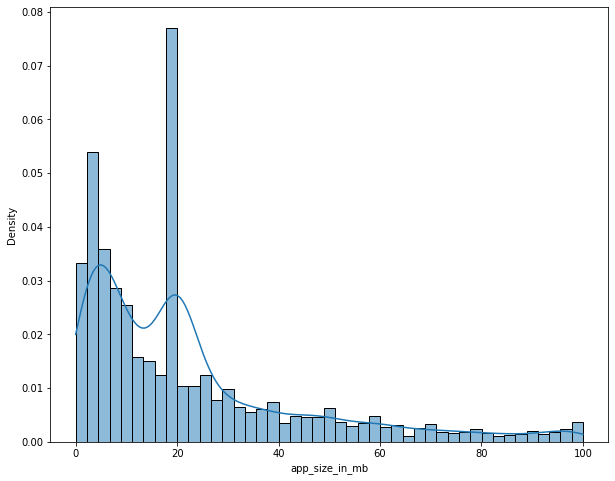

In [ ]:
# check the distribution of app sizes
plt.figure(figsize=(10,8))
sns.histplot(data=df_temp,x='app_size_in_mb',stat='density', kde = True)
plt.show()

In [ ]:
bins = [0, 20, 40, 60, 80, 100]
temp = df_temp.loc[:, ['app_category', 'app_size_in_mb']]
temp['app_size_bin'] = pd.cut(df_temp['app_size_in_mb'], bins)
temp_gp = temp.groupby('app_category')['app_size_bin'].value_counts()
temp_dff = pd.DataFrame(columns = temp.app_size_bin.unique().sort_values(), index = temp.app_category.unique())
temp_dff.head()
for i in temp_gp.index:
  temp_dff.loc[i[0], i[1]] = temp_gp.loc[i[0],i[1]]
temp_dff.head(20)
temp_dff[temp_dff.columns] = temp_dff[temp_dff.columns].astype('int')
cm = sns.light_palette("purple", as_cmap=True)
temp_dff.style.background_gradient(cmap=cm)

,"(0, 20]","(20, 40]","(40, 60]","(60, 80]","(80, 100]"
NEWS AND MAGAZINES,221,40,2,1,0
TOOLS,752,73,12,5,1
FAMILY,1057,393,251,133,109
LIFESTYLE,289,63,14,3,4
AUTO AND VEHICLES,60,16,6,1,2
PERSONALIZATION,343,30,10,4,1
PHOTOGRAPHY,249,43,26,2,2
GAME,356,271,213,144,137
SPORTS,208,94,24,14,11
EVENTS,48,14,1,1,0


**Observations**:
- The graph and table above show that major apps have an average app size of nearly 20MB. According to the table, the Family app category has a maximum app size of around 20 MB. This is due to the fact that these apps are designed to serve a single purpose, like vocabulary training, small puzzles, etc. Designing these apps takes less memory. It has also been discovered that the app category called "Family" has the greatest variation in app size. This is because many types of unique apps fall under the app category called "Family." The memory used for building these apps will vary according to different apps.

#### 4.2 Analysis on App Price

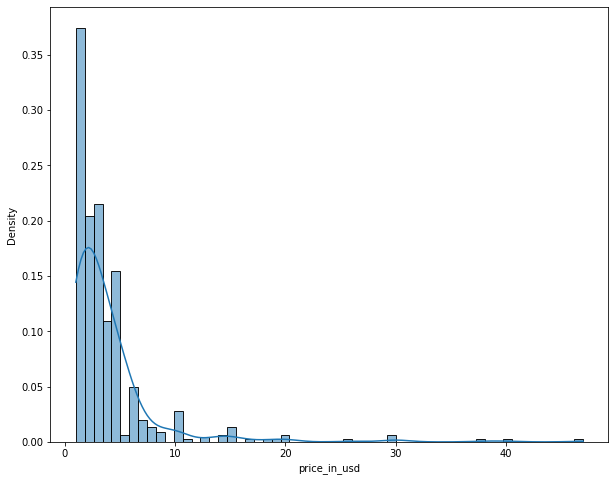

In [ ]:
plt.figure(figsize=(10,8))
# More than 95% of the app price is less than or equals to 50.
df_paid = df_temp[(df_temp['free_or_paid'] == 'Paid') & (df_temp['price_in_usd'] < 50)]
sns.histplot(data=df_paid,x='price_in_usd',stat='density',kde = True)
plt.show()

In [ ]:
bins = [0, 10, 20, 30, 40, 50]
tmp = df_paid.loc[:, ['app_category', 'price_in_usd']]
tmp['app_price_bin'] = pd.cut(df_paid['price_in_usd'], bins)
tmp_gp = tmp.groupby('app_category')['app_price_bin'].value_counts()
tmp_dff = pd.DataFrame(columns = tmp.app_price_bin.unique().sort_values(), index = tmp.app_category.unique())
for i in tmp_gp.index:
  tmp_dff.loc[i[0], i[1]] = tmp_gp.loc[i[0],i[1]]
tmp_dff.head(20)
tmp_dff[tmp_dff.columns] = tmp_dff[tmp_dff.columns].astype('int')
cm = sns.light_palette("purple", as_cmap=True)
tmp_dff.style.background_gradient(cmap=cm)

,"(0, 10]","(10, 20]","(20, 30]","(30, 40]","(40, 50]"
TOOLS,75,2,1,0,0
FAMILY,169,11,1,1,1
PERSONALIZATION,82,0,0,0,0
DATING,7,0,0,0,0
PHOTOGRAPHY,18,1,1,0,0
LIFESTYLE,12,0,0,1,0
HEALTH AND FITNESS,15,0,0,0,0
SPORTS,23,0,1,0,0
GAME,80,3,0,0,0
BOOKS AND REFERENCE,28,0,0,0,0


**Observations**:
- It has been discovered that 95% of the apps are in a price range of 0 to 50. The "Family" app category has the most apps priced between 0 and 10 USD. This is because these apps are short-lived apps designed for any specific purpose. Some of the apps are free, and some are at minimal cost.

#### 4.3 Analysis on Average screen time

<Figure size 720x576 with 0 Axes>

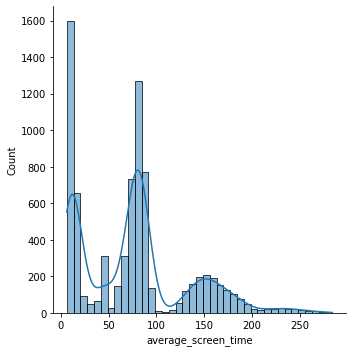

In [ ]:
plt.figure(figsize=(10,8))
sns.displot(data=df_temp,x='average_screen_time', kde = True)
plt.show()

In [ ]:
bins = [0, 50, 100, 150, 200, 250, 300]
tmp1 = df_temp.loc[:, ['app_category', 'average_screen_time']]
tmp1['app_screen_time_bin'] = pd.cut(df_temp['average_screen_time'], bins)
tmp_gp1 = tmp1.groupby('app_category')['app_screen_time_bin'].value_counts()
tmp_dff1 = pd.DataFrame(columns = tmp1.app_screen_time_bin.unique().sort_values(), index = tmp1.app_category.unique())
for i in tmp_gp1.index:
  tmp_dff1.loc[i[0], i[1]] = tmp_gp1.loc[i[0],i[1]]
tmp_dff1.head(20)
tmp_dff1[tmp_dff1.columns] = tmp_dff1[tmp_dff1.columns].astype('int')
cm = sns.light_palette("purple", as_cmap=True)
tmp_dff1.style.background_gradient(cmap=cm)

,"(0, 50]","(50, 100]","(100, 150]","(150, 200]","(200, 250]","(250, 300]"
NEWS AND MAGAZINES,0,263,1,0,0,0
TOOLS,843,0,0,0,0,0
FAMILY,0,1939,4,0,0,0
LIFESTYLE,1,372,0,0,0,0
AUTO AND VEHICLES,85,0,0,0,0,0
PERSONALIZATION,388,0,0,0,0,0
PHOTOGRAPHY,322,0,0,0,0,0
GAME,0,1,587,533,0,0
SPORTS,0,351,0,0,0,0
EVENTS,64,0,0,0,0,0


**Observations**:
- It has been discovered that the average screen time varies widely. Some apps have a low average screentime, while others have a high average screentime. When it comes to app categories, Family and Tools have less screentime because users spend less time on these apps. The Entertainment, Education, and Games app categories have high screentime because users spend a significant amount of time on these types of apps. For instance, if you watch a movie, play a game, or watch an educational video, you will spend more time. This is why these app categories have high screentime.

#### 4.4 Analysis on Active Users

<Figure size 720x576 with 0 Axes>

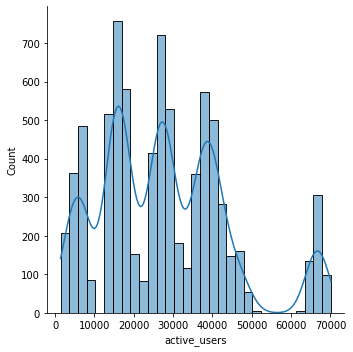

In [ ]:
plt.figure(figsize=(10,8))
sns.displot(data=df_temp,x='active_users', kde = True)
plt.show()

In [ ]:
bins = [0, 10000, 20000, 30000, 40000, 50000, 60000, 70000, 80000]
tmp2 = df_temp.loc[:, ['app_category', 'active_users']]
tmp2['active_users_bin'] = pd.cut(df_temp['active_users'], bins)
tmp_gp2 = tmp2.groupby('app_category')['active_users_bin'].value_counts()
tmp_dff2 = pd.DataFrame(columns = tmp2.active_users_bin.unique().sort_values(), index = tmp2.app_category.unique())
for i in tmp_gp2.index:
  tmp_dff2.loc[i[0], i[1]] = tmp_gp2.loc[i[0],i[1]]
tmp_dff2[tmp_dff2.columns] = tmp_dff2[tmp_dff2.columns].astype('int')
cm = sns.light_palette("purple", as_cmap=True)
tmp_dff2.style.background_gradient(cmap=cm)

,"(0, 10000]","(10000, 20000]","(20000, 30000]","(30000, 40000]","(40000, 50000]","(50000, 60000]","(60000, 70000]","(70000, 80000]"
NEWS AND MAGAZINES,0,0,0,0,0,0,262,2
TOOLS,0,840,3,0,0,0,0,0
FAMILY,0,1,1724,218,0,0,0,0
LIFESTYLE,0,0,0,355,18,0,0,0
AUTO AND VEHICLES,0,0,0,0,82,3,0,0
PERSONALIZATION,0,387,1,0,0,0,0,0
PHOTOGRAPHY,0,322,0,0,0,0,0,0
GAME,0,0,0,794,327,0,0,0
SPORTS,351,0,0,0,0,0,0,0
EVENTS,0,64,0,0,0,0,0,0


**Observations**:
- The number of active users varies significantly across app categories. Sports apps have fewer active users because users become more active when a live tournament is taking place. Maybe no sporting events are scheduled during these weeks. As a result, there are few active users. News and Magazine, and Social have a high number of active users because users are more active on social media apps, and users are more likely to watch news or magazine articles on the app itself. This could explain why these app categories have a high number of active users.

#### 4.5 Analysis on Installations

<Figure size 720x576 with 0 Axes>

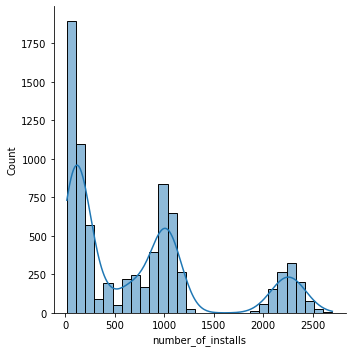

In [ ]:
plt.figure(figsize=(10,8))
sns.displot(data=df_temp,x='number_of_installs', kde = True)
plt.show()

In [ ]:
bins = [0, 500, 1000, 1500, 2000, 2500, 3000]
tmp3 = df_temp.loc[:, ['app_category', 'number_of_installs']]
tmp3['number_of_installs_bin'] = pd.cut(df_temp['number_of_installs'], bins)
tmp_gp3 = tmp3.groupby('app_category')['number_of_installs_bin'].value_counts()
tmp_dff3 = pd.DataFrame(columns = tmp3.number_of_installs_bin.unique().sort_values(), index = tmp3.app_category.unique())
for i in tmp_gp3.index:
  tmp_dff3.loc[i[0], i[1]] = tmp_gp3.loc[i[0],i[1]]
tmp_dff3[tmp_dff3.columns] = tmp_dff3[tmp_dff3.columns].astype('int')
cm = sns.light_palette("purple", as_cmap=True)
tmp_dff3.style.background_gradient(cmap=cm)

,"(0, 500]","(500, 1000]","(1000, 1500]","(1500, 2000]","(2000, 2500]","(2500, 3000]"
NEWS AND MAGAZINES,1,263,0,0,0,0
TOOLS,843,0,0,0,0,0
FAMILY,0,948,995,0,0,0
LIFESTYLE,8,365,0,0,0,0
AUTO AND VEHICLES,85,0,0,0,0,0
PERSONALIZATION,388,0,0,0,0,0
PHOTOGRAPHY,322,0,0,0,0,0
GAME,0,0,0,30,1059,32
SPORTS,351,0,0,0,0,0
EVENTS,64,0,0,0,0,0


**Observations**:
- According to the graph and table above, the app category called Tools appears to have fewer installations. This could be because they are less useful to users or because the target audience is smaller. The app category called Games has a high number of installations because users of all ages enjoy playing games.

#### 4.6 Analysis on Advertisement Revenue

<Figure size 720x576 with 0 Axes>

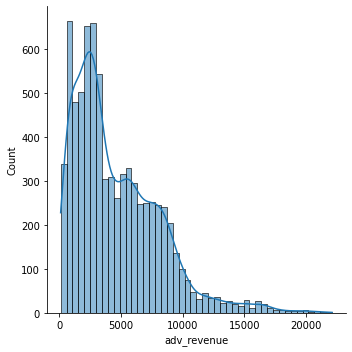

In [ ]:
plt.figure(figsize=(10,8))
sns.displot(data=df_temp,x='adv_revenue',kde=True)
plt.show()

In [ ]:
bins = [0, 5000, 10000, 15000, 20000, 25000, 30000]
tmp4 = df_temp.loc[:, ['app_category', 'adv_revenue']]
tmp4['adv_revenue_bin'] = pd.cut(df_temp['adv_revenue'], bins)
tmp_gp4 = tmp4.groupby('app_category')['adv_revenue_bin'].value_counts()
tmp_dff4 = pd.DataFrame(columns = tmp4.adv_revenue_bin.unique().sort_values(), index = tmp4.app_category.unique())
for i in tmp_gp4.index:
  tmp_dff4.loc[i[0], i[1]] = tmp_gp4.loc[i[0],i[1]]
tmp_dff4[tmp_dff4.columns] = tmp_dff4[tmp_dff4.columns].astype('int')
cm = sns.light_palette("purple", as_cmap=True)
tmp_dff4.style.background_gradient(cmap=cm)

,"(0, 5000]","(5000, 10000]","(10000, 15000]","(15000, 20000]","(20000, 25000]","(25000, 30000]"
NEWS AND MAGAZINES,0,52,164,48,0,0
TOOLS,843,0,0,0,0,0
FAMILY,1370,573,0,0,0,0
LIFESTYLE,53,312,8,0,0,0
AUTO AND VEHICLES,0,84,1,0,0,0
PERSONALIZATION,388,0,0,0,0,0
PHOTOGRAPHY,322,0,0,0,0,0
GAME,6,1016,99,0,0,0
SPORTS,351,0,0,0,0,0
EVENTS,64,0,0,0,0,0


**Observations**:
- The app category Tools generates less revenue because we observed that tools have fewer installations and, as a result, fewer ads are displayed as there are fewer users. Because the number of installations in the News & Magazine, and Social app categories is high, a greater number of ads are being broadcast to these app categories, and ads are a good source of revenue. This is the reason these app categories are generating high revenue.

### 5.0 Bivariate Analysis to answer business questions

#### 5.1 How is the revenue trending week over week?

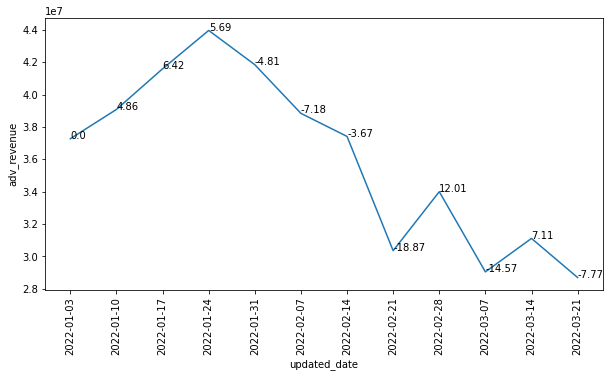

In [ ]:
temp = pd.DataFrame(df.groupby('updated_date')['adv_revenue'].sum())
temp.reset_index(level=0, inplace=True)
temp.sort_values(by='updated_date')

temp['lag(adv_revenue,1)'] = temp['adv_revenue'].shift(1)

temp['Diff'] = (temp['adv_revenue'] - temp['lag(adv_revenue,1)']) * 100 / temp['lag(adv_revenue,1)'] 
temp.fillna(0, inplace = True)


s1 = df.groupby('updated_date')['adv_revenue'].sum()
a4_dims = (10, 5)
fig, ax = plt.subplots(figsize=a4_dims)

palette = ['r','b','g']

p1 = sns.lineplot(x='updated_date', y='adv_revenue', markers=True, dashes=False, data=temp, palette=palette, ci = None, ax=ax)

for i in range(len(s1)):
    p1.annotate(str(round(temp.loc[i, 'Diff'], 2)), xy = (i,s1[i]))
plt.xticks(rotation = 90)
plt.show()

**Observations**:
- It has been observed that overall revenue increased for the first four weeks before beginning to decline. This is a major concern. We need to figure out what factors are causing the overall revenue trend to decline.


#### 5.2 Which are the categories that generate 70% of my advertising revenue?

In [ ]:
total_rev = df.groupby('app_category')['adv_revenue'].sum().sort_values(ascending=False).sum()

sum = 0
temp1 = pd.DataFrame(df.groupby('app_category')['adv_revenue'].sum().sort_values(ascending=False))
for i in temp1.adv_revenue:
  sum = sum + float(i)
  if sum * 100 / total_rev > 70:
    print(temp1.index[temp1['adv_revenue'] == float(i)])
    print(sum)
    break
  print(temp1.index[temp1['adv_revenue'] == i])

Index(['GAME'], dtype='object', name='app_category')
Index(['FAMILY'], dtype='object', name='app_category')
Index(['SOCIAL'], dtype='object', name='app_category')
Index(['NEWS AND MAGAZINES'], dtype='object', name='app_category')
Index(['LIFESTYLE'], dtype='object', name='app_category')
313586025.53999996


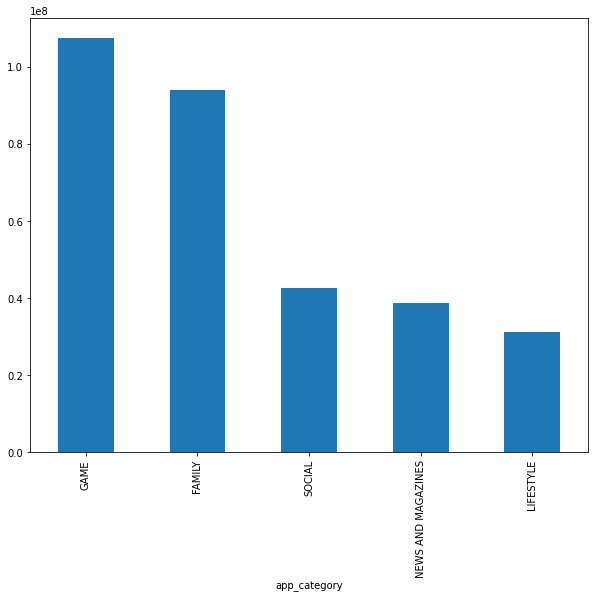

In [ ]:
plt.figure(figsize = (10,8))
temp2 = df.loc[df.app_category.isin(['GAME','FAMILY','SOCIAL', 'NEWS AND MAGAZINES','LIFESTYLE']),:]
temp2.groupby('app_category')['adv_revenue'].sum().sort_values(ascending=False).plot(kind='bar')
plt.show()

**Observations**:
- It has been observed that app categories such as Game, Family, Social, News and Magazine and Lifestyle generate the most revenue. However, it is necessary to investigate why these app categories generate so much revenue. We must identify whether these apps have a higher screentime and, as a result, generate a higher revenue.

#### 5.3 Do the top 5 revenue generating categories have significantly higher average screen time per week compared to the rest of the categories?

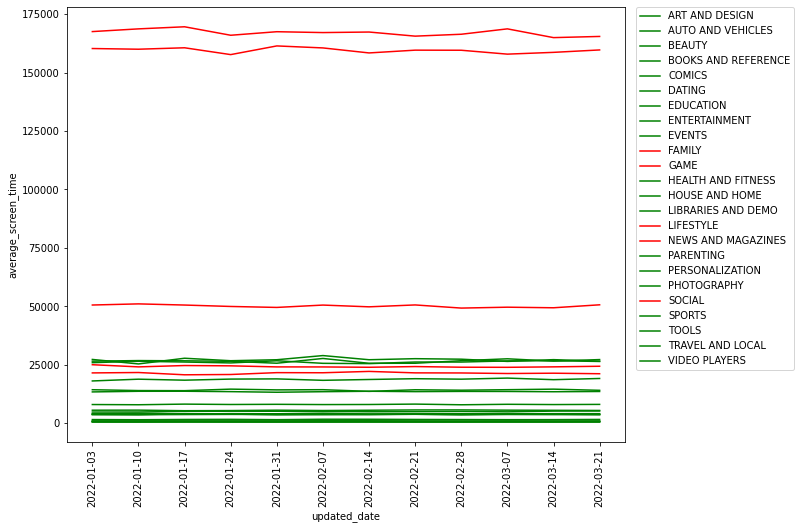

In [ ]:
custom_palette = {}
for i in df.app_category.unique():
    if i in temp2.app_category.unique():
      custom_palette[i] = 'r'
    else:
      custom_palette[i] = 'g'

plt.figure(figsize = (10, 8))
tmpp = pd.DataFrame(df.groupby(['updated_date', 'app_category'])['average_screen_time'].sum())
sns.lineplot(data = tmpp, x = 'updated_date', y = 'average_screen_time', ci = None, hue = 'app_category', palette = custom_palette)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.xticks(rotation = 90)
plt.show()

**Observations**:
- To determine whether increased screentime leads to increased revenue. This plot provides me with the solution. This plot clearly shows that the majority of the apps in the app categories with the highest revenue have the highest screentime.

#### 5.4 For the top 5 revenue generating categories, how is the revenue trending week over week?

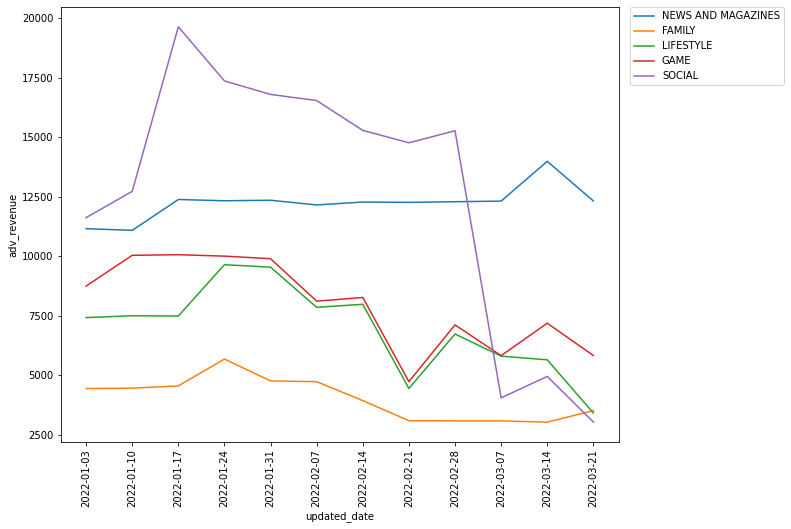

In [ ]:
temp7 = df.loc[df.app_category.isin(['GAME','FAMILY','SOCIAL', 'NEWS AND MAGAZINES','LIFESTYLE']),:]
plt.figure(figsize = (10, 8))
sns.lineplot(data = temp7, x = 'updated_date', y = 'adv_revenue', ci = None,hue = 'app_category')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.xticks(list(temp7.updated_date.unique()), rotation = 90)
plt.show()


**Observations**:
- According to the above plot, the apps that generate the most revenue show an increasing trend in revenue for the first four weeks and then a decreasing trend in the last eight weeks.It is necessary to identify the factors that contribute to declining revenue.

#### 5.5 Is the downward trend happening because of a reduction in the number of installs week over week?

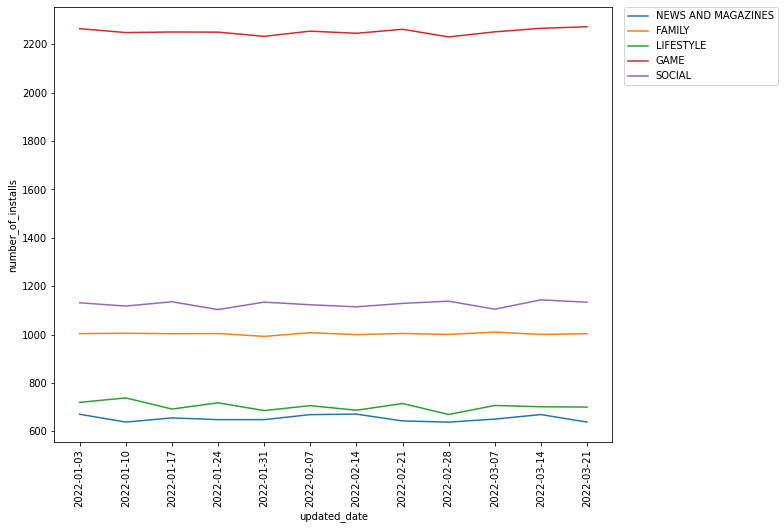

In [ ]:
temp3 = df.loc[df.app_category.isin(['GAME','FAMILY','SOCIAL', 'NEWS AND MAGAZINES','LIFESTYLE']),:]
plt.figure(figsize = (10, 8))
sns.lineplot(data = temp3, x = 'updated_date', y = 'number_of_installs', ci = None,hue = 'app_category')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.xticks(list(temp3.updated_date.unique()), rotation = 90)
plt.show()


**Observations**:
- The above plot clearly shows that the number of installations remains almost constant over the course of 12 weeks. As a result, we can conclude that the number of installs is not the primary cause of declining revenue.

#### 5.6 Is the downward trend happening because of a reduction in the number of active users week over week?

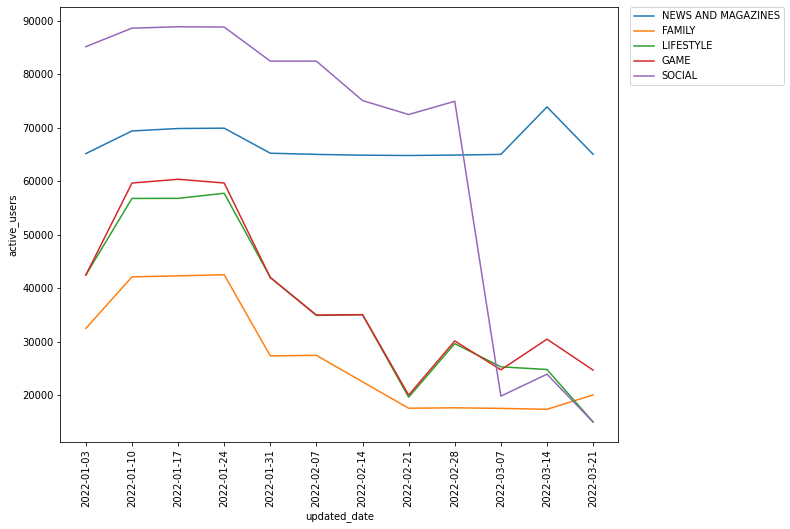

In [ ]:
plt.figure(figsize = (10, 8))
sns.lineplot(data = temp3, x = 'updated_date', y = 'active_users', ci = None,hue = 'app_category')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.xticks(list(temp3.updated_date.unique()), rotation = 90)
plt.show()

**Observations**:
- From the above plot, it is clearly seen that the number of active users is decreasing for the top 5 revenue-generating app categories over the last 8 weeks.Need to find out why active users are decreasing over the last 8 weeks.

#### 5.7 Why are active users decreasing? Could it be because of the increase in the number of short and long ads per hour? Could this be hampering user experience, leading to lower customer engagement?

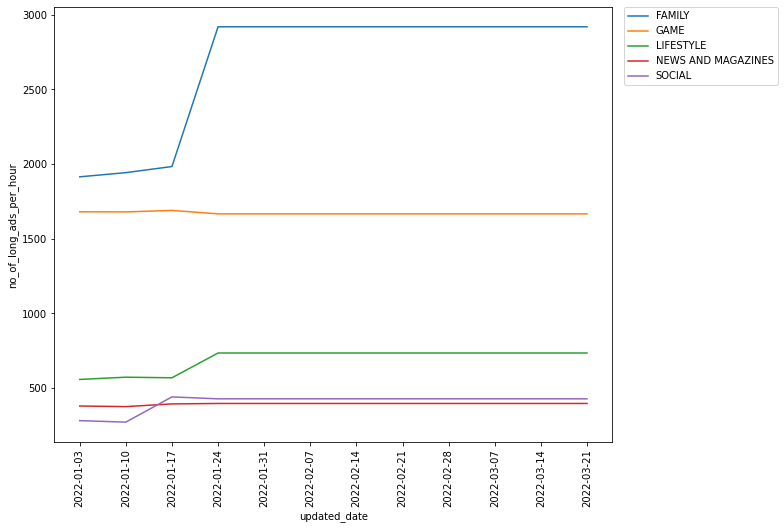

In [ ]:
plt.figure(figsize = (10, 8))
temp4 = pd.DataFrame(temp3.groupby(['updated_date', 'app_category'])['no_of_long_ads_per_hour'].sum())
sns.lineplot(data = temp4, x = 'updated_date', y = 'no_of_long_ads_per_hour', ci = None, hue = 'app_category')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.xticks(rotation = 90)
plt.show()

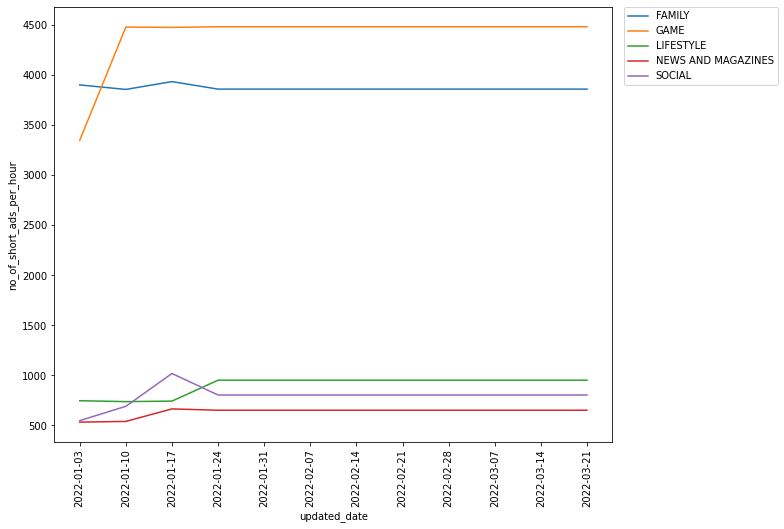

In [ ]:
plt.figure(figsize = (10, 8))
temp5 = pd.DataFrame(temp3.groupby(['updated_date', 'app_category'])['no_of_short_ads_per_hour'].sum())
sns.lineplot(data = temp5, x = 'updated_date', y = 'no_of_short_ads_per_hour', ci = None, hue = 'app_category')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.xticks(rotation = 90)
plt.show()

**Observations**:
- From the above 2 plots, we observed that the number of long and short ads increased for the first 4 weeks, and after the that it remained constant for the rest of the weeks. It may be because of this reason that the active users started decreasing because of the frequency of the ads, and as a result, revenue is decreasing.

### 6.0 Insights and Recommendations

- It can be seen that revenue increased for the first four weeks before declining over the next eight weeks.
- It can be seen that app categories such as "Game," "Social," "Family," "Lifestyle," and "News & Magazine" generate the most revenue.
- The above-mentioned categories experience the greatest revenue fluctuation.
- For the top five revenue generator app categories mentioned, the number of short ads per hour and long ads per hour has gradually increased and after the threshold value is remains constant.
- In the top five revenue generator app categories mentioned, the number of active users is decreasing.
- From the above plots and the observations, it can be highlighted that the major revenue drop is because the active users are dropping for the top 5 categories, and the reason for the decrease in active users is because the number of short and long ads in an hour is increasing for these top 5 app categories. Because these app categories play a significant role in revenue generation, a decrease in revenue for these top 5 categories will reduce overall revenue over time.
- Finally, we can state that an increase in the number of ads reduces the number of active users and, as a result, revenue.
-The company should focus on both revenue generation and user attrition. Increasing ads after a certain amount will result in a decrease in revenue.
- The company should broadcast different ads in each app category on an equal propertion basis.
- The company should also consider what users like about the advertisements. Ads that users enjoy should be broadcasted.
